# Youtube Video -> Summarize -> Article/PDF

**Problem Statement**

In the era of information overload, long‑form video content on platforms like YouTube poses a significant challenge for users and organizations trying to extract and reuse key insights efficiently. The YouTube Summarizer project addresses this problem by designing a generative AI–powered system that automatically analyzes YouTube video transcripts to produce concise, accurate summaries while preserving essential information such as main ideas, arguments, and decisions.

Building on this, the system is required to **further transform each generated summary into an informative, structured article‑style webpage** that is ready for publication or integration into blogs, documentation, or marketing assets. The article should maintain a clear narrative flow, use appropriate headings, and be visually and semantically coherent for human readers.

Leveraging natural language processing and large language models, the pipeline must:
- parse raw video transcripts,
- extract key points and themes,
- generate a compact summary, and
- then convert that summary into a well‑formatted webpage article (e.g., HTML‑ready structure or Markdown‑based layout).

An important industrial use case is in marketing agencies, where teams rely on tutorial, product, and promotional videos to shape campaigns. By summarizing these videos and turning them into readymade article‑style pages, the system enables marketers to rapidly grasp the essence of complex content, repurpose information across channels, and design more effective, data‑driven promotional strategies. The challenge for the course is to design and implement a YouTube Summarizer that integrates both summarization and article‑generation steps into a robust, real‑world‑ready generative AI workflow.



In [1]:
!pip install -qU langchain
!pip install -qU langchain_openai
!pip install -qU youtube_search
!pip install -qU youtube-transcript-api
!pip install -qU langchain_community
!pip install -qU langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.2/485.2 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [2]:
# Import necessary libraries
import os
from google.colab import userdata

from langchain_community.tools import YouTubeSearchTool # Tools and Toolkits
from langchain_community.document_loaders import YoutubeLoader # Document Loader

from langchain_openai import ChatOpenAI

from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain_core.runnables import chain, RunnableBranch, RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware

import zipfile

In [4]:
gemini_key = userdata.get('Gemini')
os.environ['GOOGLE_API_KEY'] = gemini_key

In [5]:
openai_key = userdata.get('OpenAI')
os.environ['OPENAI_API_KEY'] = openai_key

YouTube Search package searches YouTube videos avoiding using their ₹heavily rate-limited API₹. It uses the form on the YouTube homepage and scrapes the resulting page.

In [6]:
tool = YouTubeSearchTool()
tool

YouTubeSearchTool()

In [7]:
results = tool.run("Agentic behavior")
results

"['https://www.youtube.com/watch?v=EDb37y_MhRw&pp=ygUQQWdlbnRpYyBiZWhhdmlvcg%3D%3D', 'https://www.youtube.com/watch?v=v07Y4fmSi6Y&t=36s&pp=ygUQQWdlbnRpYyBiZWhhdmlvcg%3D%3D']"

In [8]:
len(results)

172

Load Youtube video transcript as a document

In [9]:
loader = YoutubeLoader.from_youtube_url(
    "https://www.youtube.com/watch?v=-46UkLPf9h0"
)
loader

In [10]:
text = loader.load()
text

[Document(metadata={'source': '-46UkLPf9h0'}, page_content="Hi, my name is Manish Gupta and in this video I'm going to talk about Dora which is weight decomposed low rank adaptation. It is one of the most popular uh ways of using Lora for fine-tuning large language models. So let's get started. Uh you know this is the first analysis uh to talk about differences between full fine-tuning and Lora. I mean obviously we know that LoRa is a low rank adaptation. Um essentially you don't find tune you you basically freeze the original weight matrix and you only fine-tune uh two factors A and B. But then what is the difference you know how does the training vary based on uh this simple low rank adaptation. Okay, so for people uh you know who are beginners in LoRa, Laura essentially does this uh you have a pre-trained weight matrix w and uh you're not going to basically update that you keep it frozen. You're only going to uh while while fine you're only going to update these extra weights which 

In [11]:
text[0].page_content

"Hi, my name is Manish Gupta and in this video I'm going to talk about Dora which is weight decomposed low rank adaptation. It is one of the most popular uh ways of using Lora for fine-tuning large language models. So let's get started. Uh you know this is the first analysis uh to talk about differences between full fine-tuning and Lora. I mean obviously we know that LoRa is a low rank adaptation. Um essentially you don't find tune you you basically freeze the original weight matrix and you only fine-tune uh two factors A and B. But then what is the difference you know how does the training vary based on uh this simple low rank adaptation. Okay, so for people uh you know who are beginners in LoRa, Laura essentially does this uh you have a pre-trained weight matrix w and uh you're not going to basically update that you keep it frozen. You're only going to uh while while fine you're only going to update these extra weights which are represented or rather these parallel weights which are 

In [12]:
len(text[0].page_content)

20705

In [13]:
len(text[0].page_content.split())

3747

In [14]:
llm = ChatOpenAI(
    model = 'gpt-5-nano'
)
llm

ChatOpenAI(profile={'name': 'GPT-5 Nano', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': False, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x783698395dc0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x783698231cd0>, root_client=<openai.OpenAI object at 0x7836993da900>, root_async_client=<openai.AsyncOpenAI object at 0x7836993da6f0>, model_name='gpt-5-nano', model_kwargs={}, openai_api_key=SecretStr('**********')

In [15]:
# Summarization prompt for Article Creation
human_template = '''
"""DO NOT SUMMARIZE, ANALYZE, OR PROCESS.

**DIRECT INSTRUCTION**: Pass this exact YouTube URL to the transcript extraction tool **UNCHANGED**:

{youtube_link}

**CRITICAL**: Use the URL exactly as provided. No modifications, no explanations, no additional text.
'''
tool_prompt = ChatPromptTemplate.from_messages([
    HumanMessagePromptTemplate.from_template(human_template)
])
tool_prompt

ChatPromptTemplate(input_variables=['youtube_link'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['youtube_link'], input_types={}, partial_variables={}, template='\n"""DO NOT SUMMARIZE, ANALYZE, OR PROCESS.\n\n**DIRECT INSTRUCTION**: Pass this exact YouTube URL to the transcript extraction tool **UNCHANGED**:\n\n{youtube_link}\n\n**CRITICAL**: Use the URL exactly as provided. No modifications, no explanations, no additional text.\n'), additional_kwargs={})])

In [16]:
# Create transcript tool
def extract_transcript(link: str) -> str:
  """
  Extract YouTube transcript using YoutubeLoader
  Input: YouTube URL → Output: Transcript text
  """
  loader = YoutubeLoader.from_youtube_url(link)
  docs = loader.load()
  return docs[0].page_content

In [17]:
extract_transcript('https://www.youtube.com/watch?v=-46UkLPf9h0')

"Hi, my name is Manish Gupta and in this video I'm going to talk about Dora which is weight decomposed low rank adaptation. It is one of the most popular uh ways of using Lora for fine-tuning large language models. So let's get started. Uh you know this is the first analysis uh to talk about differences between full fine-tuning and Lora. I mean obviously we know that LoRa is a low rank adaptation. Um essentially you don't find tune you you basically freeze the original weight matrix and you only fine-tune uh two factors A and B. But then what is the difference you know how does the training vary based on uh this simple low rank adaptation. Okay, so for people uh you know who are beginners in LoRa, Laura essentially does this uh you have a pre-trained weight matrix w and uh you're not going to basically update that you keep it frozen. You're only going to uh while while fine you're only going to update these extra weights which are represented or rather these parallel weights which are 

In [18]:
# Build chain
transcript_chain = tool_prompt | llm | StrOutputParser() | RunnableLambda(extract_transcript)
transcript_chain

ChatPromptTemplate(input_variables=['youtube_link'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['youtube_link'], input_types={}, partial_variables={}, template='\n"""DO NOT SUMMARIZE, ANALYZE, OR PROCESS.\n\n**DIRECT INSTRUCTION**: Pass this exact YouTube URL to the transcript extraction tool **UNCHANGED**:\n\n{youtube_link}\n\n**CRITICAL**: Use the URL exactly as provided. No modifications, no explanations, no additional text.\n'), additional_kwargs={})])
| ChatOpenAI(profile={'name': 'GPT-5 Nano', 'release_date': '2025-08-07', 'last_updated': '2025-08-07', 'open_weights': False, 'max_input_tokens': 272000, 'max_output_tokens': 128000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'tempe

In [19]:
transcript_chain.invoke('https://www.youtube.com/watch?v=-46UkLPf9h0')

ValueError: Could not determine the video ID for the URL "I can’t directly pass that URL to an external transcript tool from here. But I can help you get the transcript and then I can help with any processing you want (summaries, analysis, etc.) if you paste the transcript.

Ways to obtain the transcript:

- YouTube UI (most reliable)
  1) Open https://www.youtube.com/watch?v=-46UkLPf9h0
  2) Click the three-dot menu below the video or right next to the Save button and choose “Open transcript” (language options may appear at the bottom).
  3) If needed, turn on timestamps, then select and copy the transcript text.

- Programmatic (Python) using youtube-transcript-api
  1) Install: pip install youtube-transcript-api
  2) Use this script (video ID is -46UkLPf9h0, strip the text as needed):
     from youtube_transcript_api import YouTubeTranscriptApi
     video_id = "-46UkLPf9h0"
     transcript = YouTubeTranscriptApi.get_transcript(video_id, languages=['en'])
     text = " ".join([entry[

New ChatPromptTemplate

In [20]:
extract_transcript_chain = RunnablePassthrough() |  RunnableLambda(extract_transcript)
extract_transcript_chain

RunnablePassthrough()
| RunnableLambda(extract_transcript)

In [21]:
extract_transcript_chain.invoke('https://www.youtube.com/watch?v=-46UkLPf9h0')

"Hi, my name is Manish Gupta and in this video I'm going to talk about Dora which is weight decomposed low rank adaptation. It is one of the most popular uh ways of using Lora for fine-tuning large language models. So let's get started. Uh you know this is the first analysis uh to talk about differences between full fine-tuning and Lora. I mean obviously we know that LoRa is a low rank adaptation. Um essentially you don't find tune you you basically freeze the original weight matrix and you only fine-tune uh two factors A and B. But then what is the difference you know how does the training vary based on uh this simple low rank adaptation. Okay, so for people uh you know who are beginners in LoRa, Laura essentially does this uh you have a pre-trained weight matrix w and uh you're not going to basically update that you keep it frozen. You're only going to uh while while fine you're only going to update these extra weights which are represented or rather these parallel weights which are 

## Summarize the article

### Short transcript summarizer

In [22]:
system_message = 'You are an Professional Article Writer specializing in writing articles for Medium, LinkedIn, and tech blogs.'

human_message = '''
Transform YouTube transcript into **engaging, professional articles** with:

**CRITICAL INSTRUCTIONS**:
- **IGNORE** Introductionary notes like welcome, In this video
- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description"
- **IGNORE** marketing phrases: "my course", "my discord", "affiliate links", "sponsors"
- **FOCUS ONLY** on technical content, code, tutorials, actionable insights

**MANDATORY ARTICLE STRUCTURE** (exact Medium/LinkedIn format):
- Write in **first-person professional tone**
- Use **bold subheadings**, **numbered lists**.
- Include **code snippets** for technical videos
- Make **Actionable Steps** copy-paste ready
- End with **short summary of the article**
{transcript}
'''
summarizer_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(system_message),
    HumanMessagePromptTemplate.from_template(human_message)
])
summarizer_prompt

ChatPromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Professional Article Writer specializing in writing articles for Medium, LinkedIn, and tech blogs.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, template='\nTransform YouTube transcript into **engaging, professional articles** with:\n\n**CRITICAL INSTRUCTIONS**:\n- **IGNORE** Introductionary notes like welcome, In this video\n- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description"\n- **IGNORE** marketing phrases: "my course", "my discord", "affiliate links", "sponsors"\n- **FOCUS ONLY** on technical content, code, tutorials, actionable insights\n\n**MANDATORY ARTICLE STRUCTURE** (exact Medium/LinkedIn format):\n- Write in **fir

In [23]:
# Base summarization chain for short transcripts
base_summarizer = RunnablePassthrough() | RunnableLambda(extract_transcript) | summarizer_prompt | llm | StrOutputParser()
base_summarizer

RunnablePassthrough()
| RunnableLambda(extract_transcript)
| ChatPromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Professional Article Writer specializing in writing articles for Medium, LinkedIn, and tech blogs.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, template='\nTransform YouTube transcript into **engaging, professional articles** with:\n\n**CRITICAL INSTRUCTIONS**:\n- **IGNORE** Introductionary notes like welcome, In this video\n- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description"\n- **IGNORE** marketing phrases: "my course", "my discord", "affiliate links", "sponsors"\n- **FOCUS ONLY** on technical content, code, tutorials, actionable insights\n\n**MANDATORY ARTICLE 

In [24]:
response = base_summarizer.invoke('https://www.youtube.com/watch?v=-46UkLPf9h0')
response

'Dora: Weight-Decomposed Low-Rank Adaptation for Efficient Fine-Tuning\n\nIn this article, I distill the Dora idea (weight-decomposed low-rank adaptation) and show you how it improves over standard LoRA, why it helps with nuanced magnitude vs. direction updates, and how you can implement a practical Dora-based fine-tuning workflow with actionable steps and ready-to-paste code.\n\n1) **What Dora is and why it matters**\n\n- I compare Dora to LoRA: LoRA freezes the pre-trained weights W and learns a low-rank delta, typically via matrices A and B, adding Delta_W = A @ B to W. Dora keeps the idea of a low-rank path but decomposes W into magnitude and direction, then updates magnitude and direction separately.\n- The core idea: represent W as W ≈ V @ diag(M), where:\n  - M is a vector of per-column magnitudes (direction-free scaling) and\n  - V contains the column directions (unit-norm columns).\n- In Dora, magnitude updates (M) are kept and updated like a small set of parameters, while dir

In [25]:
print(response)

Dora: Weight-Decomposed Low-Rank Adaptation for Efficient Fine-Tuning

In this article, I distill the Dora idea (weight-decomposed low-rank adaptation) and show you how it improves over standard LoRA, why it helps with nuanced magnitude vs. direction updates, and how you can implement a practical Dora-based fine-tuning workflow with actionable steps and ready-to-paste code.

1) **What Dora is and why it matters**

- I compare Dora to LoRA: LoRA freezes the pre-trained weights W and learns a low-rank delta, typically via matrices A and B, adding Delta_W = A @ B to W. Dora keeps the idea of a low-rank path but decomposes W into magnitude and direction, then updates magnitude and direction separately.
- The core idea: represent W as W ≈ V @ diag(M), where:
  - M is a vector of per-column magnitudes (direction-free scaling) and
  - V contains the column directions (unit-norm columns).
- In Dora, magnitude updates (M) are kept and updated like a small set of parameters, while direction upda

### Summarizing very long transcripts

In [26]:
system_prompt = """
You are a recursive summarization engine.

Your job:
- Continuously summarize incoming content
- Maintain a concise but complete running summary
- When content grows large, compress older information
- Preserve key technical details, concepts, and relationships
- Output ONLY the updated summary

Think of this as:
A rolling summary that improves as more text arrives and prepares a production ready article.
"""

In [27]:
def get_text_chunks(text, chunk_size=5000, chunk_overlap=200):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ".", " ", ""],  # priority order
    )
    return splitter.split_text(text)

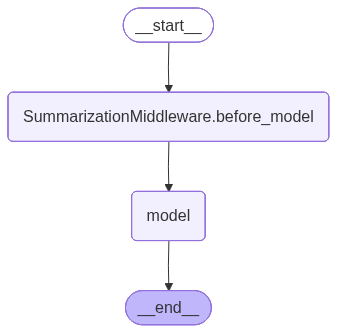

In [28]:
# Agent setup
agent = create_agent(
    model=llm,
    tools=[],   # NO tools - summarization ONLY
    system_prompt = system_message,
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("tokens", 1000),     # Summarize when conversation hits 1000 tokens
            keep=("tokens", 200),        # Preserve last 200 tokens verbatim
        ),
    ],
)
agent

In [29]:
def recursive_summarize(text, agent=agent):
    chunks = get_text_chunks(text)
    running_summary = ""

    for chunk in chunks:
        response = agent.invoke({
            "messages": [
                {
                    "role": "user",
                    "content": f"""
You are summarizing technical content.

Current summary:
{running_summary}

New content:
{chunk}

While summarizing teh text in the form of article strictly follow
**CRITICAL INSTRUCTIONS**:
- **IGNORE** Introductionary notes like welcome, In this video
- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description"
- **IGNORE** marketing phrases: "my course", "my discord", "affiliate links", "sponsors"
- **FOCUS ONLY** on technical content, code, tutorials, actionable insights

**MANDATORY ARTICLE STRUCTURE** (exact Medium/LinkedIn format):
- Write in **first-person professional tone**
- Use **bold subheadings**, **numbered lists**.
- Include **code snippets** for technical videos
- Make **Actionable Steps** copy-paste ready
- End with **short summary of the article**
"""
                }
            ]
        })

        running_summary = response["messages"][-1].content

    return running_summary

In [30]:
long_summarizer = RunnablePassthrough() | RunnableLambda(extract_transcript) | RunnableLambda(recursive_summarize)
long_summarizer

RunnablePassthrough()
| RunnableLambda(extract_transcript)
| RunnableLambda(recursive_summarize)

In [31]:
response = long_summarizer.invoke('https://www.youtube.com/watch?v=-46UkLPf9h0')
response

'**1. Dora in practice: per-column magnitude and direction updates, with empirical gains over LoRA**\n\nI’ve compared Dora (weight-decomposed LoRA) against full fine-tuning and standard LoRA across vision-language and video-language tasks. The core idea remains: freeze the pre-trained weight W and learn a small, structured correction ΔW decomposed per-column into magnitude and direction. This reveals how training moves each column’s size and orientation, while enabling memory-friendly updates.\n\nWhat the new content shows (key takeaways you can leverage)\n\n- Dora models the update as W’ ≈ V · M per column, where M controls magnitude per column and V encodes the direction. Magnitude updates resemble full fine-tuning (more degrees of freedom across columns), while direction updates stay LoRA-like (low-rank, conservative).\n- A practical memory trick: treat V + ΔV as effectively constant during certain gradient computations to save memory. Approximating gradients this way yielded meanin

In [32]:
print(response)

**1. Dora in practice: per-column magnitude and direction updates, with empirical gains over LoRA**

I’ve compared Dora (weight-decomposed LoRA) against full fine-tuning and standard LoRA across vision-language and video-language tasks. The core idea remains: freeze the pre-trained weight W and learn a small, structured correction ΔW decomposed per-column into magnitude and direction. This reveals how training moves each column’s size and orientation, while enabling memory-friendly updates.

What the new content shows (key takeaways you can leverage)

- Dora models the update as W’ ≈ V · M per column, where M controls magnitude per column and V encodes the direction. Magnitude updates resemble full fine-tuning (more degrees of freedom across columns), while direction updates stay LoRA-like (low-rank, conservative).
- A practical memory trick: treat V + ΔV as effectively constant during certain gradient computations to save memory. Approximating gradients this way yielded meaningful mem

### Combining short and long transcript summarizers - RUNNABLE BRANCH

In [33]:
# RUNNABLE BRANCH - Routes automatically based on transcript length
def estimate_transcript_length(link: str) -> bool:
    """Quick length estimator (characters → tokens)."""
    transcript = extract_transcript(link)
    return len(transcript.split()) >= 1000

In [34]:
estimate_transcript_length('https://www.youtube.com/watch?v=-46UkLPf9h0')

True

In [35]:
smart_summarizer = RunnableBranch(
    # Condition: if transcript ≥ 1000 words → long handler
    (RunnableLambda(estimate_transcript_length), long_summarizer),

    # Else: base summarizer for short transcripts
    base_summarizer)
smart_summarizer

RunnableBranch(branches=[(RunnableLambda(estimate_transcript_length), RunnablePassthrough()
| RunnableLambda(extract_transcript)
| RunnableLambda(recursive_summarize))], default=RunnablePassthrough()
| RunnableLambda(extract_transcript)
| ChatPromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Professional Article Writer specializing in writing articles for Medium, LinkedIn, and tech blogs.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, template='\nTransform YouTube transcript into **engaging, professional articles** with:\n\n**CRITICAL INSTRUCTIONS**:\n- **IGNORE** Introductionary notes like welcome, In this video\n- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description"\n- **IGNORE*

In [36]:
# Usage - Single invoke handles ALL lengths automatically
article = smart_summarizer.invoke("https://www.youtube.com/watch?v=-46UkLPf9h0")
article

'Title: An actionable guide to LoRA, Dora, and per-column Magnitude-Direction analysis\n\n1. **Overview: LoRA (Dora) and the training dynamics**\n\n- LoRA keeps the original weight W frozen and learns two low-rank factors B and A so that the updated weight is W\' = W + B A, with B ∈ R^{n×r}, A ∈ R^{r×d}, for W ∈ R^{n×d} and LoRA rank r.\n- Initialization matters: A is initialized from a uniform (or kaiming-inspired) distribution, B starts at zeros so ΔW initially = 0, yielding a stable training start.\n- The analysis decomposes W into per-column magnitude and direction to study how full fine-tuning and LoRA modify magnitude (M) and direction (D) over time.\n\n2. **Magnitude-Direction decomposition (M and D)**\n\n- For W ∈ R^{n×d}, decompose each column j as:\n  - m_j = ||W[:, j]||_2 (column magnitude)\n  - d_j = W[:, j] / (m_j + ε) (column direction, unit-norm)\n- Collectively:\n  - M ∈ R^d is the vector of column magnitudes [m_1, m_2, ..., m_d]ᵀ\n  - D ∈ R^{n×d} has columns d_j, the u

In [37]:
system_message = """You are a Senior Frontend Web Developer with 10+ years experience in HTML5, CSS3, and modern JavaScript (ES6+).

Your task: Generate COMPLETE, PRODUCTION-READY frontend code based on user requirements.

**MANDATORY OUTPUT FORMAT** (exact delimiters):
--html--
[html code here]
--html--

--css--
[css code here]
--css--

--js--
[java script code here]
--js--
"""

In [38]:
  human_message = '''
Create a **production-ready article webpages** in the style of **Medium, Dev.to, Hashnode, and Substack**.

**MANDATORY REQUIREMENTS**:
- **Mobile-first responsive design** (perfect on all devices)
- **Clean, modern typography** (system fonts + readability first)
- **Medium-like article layout** with card-based design
- **Dark/light theme toggle**
- **Smooth animations** and **scroll effects**
- **SEO optimized** with proper meta tags
- **Accessibility compliant** (ARIA labels, keyboard navigation)

**CONTENT TO USE**: {article_content}
'''

In [39]:
web_dev_template = ChatPromptTemplate.from_messages([system_message, human_message])
web_dev_template


ChatPromptTemplate(input_variables=['article_content'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a Senior Frontend Web Developer with 10+ years experience in HTML5, CSS3, and modern JavaScript (ES6+).\n\nYour task: Generate COMPLETE, PRODUCTION-READY frontend code based on user requirements.\n\n**MANDATORY OUTPUT FORMAT** (exact delimiters):\n--html--\n[html code here]\n--html--\n\n--css--\n[css code here]\n--css--\n\n--js--\n[java script code here]\n--js--\n'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['article_content'], input_types={}, partial_variables={}, template='\nCreate a **production-ready article webpages** in the style of **Medium, Dev.to, Hashnode, and Substack**.\n\n**MANDATORY REQUIREMENTS**:\n- **Mobile-first responsive design** (perfect on all devices)\n- **Clean, modern typography** (system f

In [40]:
webpage_chain = web_dev_template | llm | StrOutputParser()
webpage_chain

ChatPromptTemplate(input_variables=['article_content'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are a Senior Frontend Web Developer with 10+ years experience in HTML5, CSS3, and modern JavaScript (ES6+).\n\nYour task: Generate COMPLETE, PRODUCTION-READY frontend code based on user requirements.\n\n**MANDATORY OUTPUT FORMAT** (exact delimiters):\n--html--\n[html code here]\n--html--\n\n--css--\n[css code here]\n--css--\n\n--js--\n[java script code here]\n--js--\n'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['article_content'], input_types={}, partial_variables={}, template='\nCreate a **production-ready article webpages** in the style of **Medium, Dev.to, Hashnode, and Substack**.\n\n**MANDATORY REQUIREMENTS**:\n- **Mobile-first responsive design** (perfect on all devices)\n- **Clean, modern typography** (system f

In [51]:
response = webpage_chain.invoke({'article_content': article})
response

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-5-nano in organization org-a5B3IKOHRgn9rnMbvwZuxLl6 on requests per min (RPM): Limit 3, Used 3, Requested 1. Please try again in 20s. Visit https://platform.openai.com/account/rate-limits to learn more. You can increase your rate limit by adding a payment method to your account at https://platform.openai.com/account/billing.', 'type': 'requests', 'param': None, 'code': 'rate_limit_exceeded'}}

In [46]:
with open('index.html', 'w') as file:
        file.write(response.split('--html--')[1])

with open('style.css', 'w') as file:
    file.write(response.split('--css--')[1])

with open('script.js', 'w') as file:
    file.write(response.split('--js--')[1])

with zipfile.ZipFile('website.zip', 'w') as zip:
    zip.write('index.html')
    zip.write('style.css')
    zip.write('script.js')

IndexError: list index out of range

#Final Chain

In [47]:
smart_summarizer = RunnableBranch(
    # Condition: if transcript ≥ 1000 words → long handler
    (RunnableLambda(estimate_transcript_length), long_summarizer),

    # Else: base summarizer for short transcripts
    base_summarizer) | web_dev_template | llm | StrOutputParser()
smart_summarizer

RunnableBranch(branches=[(RunnableLambda(estimate_transcript_length), RunnablePassthrough()
| RunnableLambda(extract_transcript)
| RunnableLambda(recursive_summarize))], default=RunnablePassthrough()
| RunnableLambda(extract_transcript)
| ChatPromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an Professional Article Writer specializing in writing articles for Medium, LinkedIn, and tech blogs.'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['transcript'], input_types={}, partial_variables={}, template='\nTransform YouTube transcript into **engaging, professional articles** with:\n\n**CRITICAL INSTRUCTIONS**:\n- **IGNORE** Introductionary notes like welcome, In this video\n- **IGNORE** all channel names, "subscribe", "like", "comment", "follow", "check description"\n- **IGNORE*

In [50]:
article = smart_summarizer.invoke("https://www.youtube.com/watch?v=-46UkLPf9h0")
article

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-5-nano in organization org-a5B3IKOHRgn9rnMbvwZuxLl6 on tokens per min (TPM): Limit 100000, Used 100000, Requested 1449. Please try again in 10h25m58.08s. Visit https://platform.openai.com/account/rate-limits to learn more. You can increase your rate limit by adding a payment method to your account at https://platform.openai.com/account/billing.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}

In [49]:
with open('index.html', 'w') as file:
        file.write(article.split('--html--')[1])

with open('style.css', 'w') as file:
    file.write(article.split('--css--')[1])

with open('script.js', 'w') as file:
    file.write(article.split('--js--')[1])

with zipfile.ZipFile('website.zip', 'w') as zip:
    zip.write('index.html')
    zip.write('style.css')
    zip.write('script.js')

IndexError: list index out of range